# 04 - Deflacao dos custos por IPCA

## tl;dr
Este notebook converte custos historicos nominais para valores de dezembro de 2025 usando IPCA mensal do SGS/BCB, serie 433.

## Context & Methods

A deflacao evita que inflacao historica seja confundida com aumento real de custo de manutencao.

### Key Assumptions
- Mes-base: `2025-12`.
- Fonte: Banco Central do Brasil, SGS serie 433, IPCA mensal em percentual.
- O fator aplicado e `indice_mes_base / indice_mes`.

In [25]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
(PROJECT_ROOT / ".cache" / "matplotlib").mkdir(parents=True, exist_ok=True)

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
TABLES = REPORTS / "tables"
ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END_EXCLUSIVE = pd.Timestamp("2026-01-01")
ANALYSIS_END = pd.Timestamp("2025-12-31")
KM_MIN_MES_ALVO = 500.0
PREVENTIVE_VMRS_CODES = {"PM"}

for path in [DATA_INTERIM, DATA_PROCESSED, FIGURES, TABLES]:
    path.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

FILES = {
    "dim_carretas": DATA_RAW / "dim_carretas_2020-01-01_to_2025-12-31.csv",
    "fato_contratos": DATA_RAW / "fato_contratos_2020-01-01_to_2025-12-31.csv",
    "fato_gps": DATA_RAW / "fato_gps_2020-01-01_to_2025-12-31.csv",
    "fato_readings": DATA_RAW / "fato_readings_2020-01-01_to_2025-12-31.csv",
    "fato_wo": DATA_RAW / "fato_wo_2020-01-01_to_2025-12-31.csv",
    "fato_wo_labour": DATA_RAW / "fato_wo_labour_2020-01-01_to_2025-12-31.csv",
    "fato_wo_parts": DATA_RAW / "fato_wo_parts_2020-01-01_to_2025-12-31.csv",
}

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

def read_csv(name: str, **kwargs) -> pd.DataFrame:
    return normalize_columns(pd.read_csv(FILES[name], low_memory=False, **kwargs))

def month_start(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce").dt.to_period("M").dt.to_timestamp()

def as_number(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def mode_or_unknown(series: pd.Series, unknown: str = "SEM_INFORMACAO") -> str:
    values = series.dropna().astype(str)
    if values.empty:
        return unknown
    return values.mode().iloc[0]

## Data

### 1. Carregar base mensal e IPCA

In [26]:
base = pd.read_csv(DATA_PROCESSED / "base_mensal_carreta.csv", parse_dates=["ano_mes"], low_memory=False)
ipca_path = DATA_RAW / "ipca_mensal_bcb_2020_2025.csv"
ipca = pd.read_csv(ipca_path, parse_dates=["ano_mes"])
ipca["ipca_pct"] = as_number(ipca["ipca_pct"])
ipca.head()

,ano_mes,ipca_pct,fonte,consulta
0,2020-01-01,0.21,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....
1,2020-02-01,0.25,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....
2,2020-03-01,0.07,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....
3,2020-04-01,-0.31,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....
4,2020-05-01,-0.38,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....


### 2. Calcular indice acumulado e fator de correcao

In [27]:
MES_BASE = pd.Timestamp("2025-12-01")
ipca = ipca.sort_values("ano_mes").copy()
ipca["indice_ipca"] = (1 + ipca["ipca_pct"] / 100).cumprod()
indice_base = float(ipca.loc[ipca["ano_mes"] == MES_BASE, "indice_ipca"].iloc[0])
ipca["fator_ipca_para_2025_12"] = indice_base / ipca["indice_ipca"]
ipca.to_csv(TABLES / "04_ipca_fatores.csv", index=False)
ipca.tail()

,ano_mes,ipca_pct,fonte,consulta,indice_ipca,fator_ipca_para_2025_12
67,2025-08-01,-0.11,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....,1.376606,1.010839
68,2025-09-01,0.48,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....,1.383213,1.006011
69,2025-10-01,0.09,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....,1.384458,1.005106
70,2025-11-01,0.18,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....,1.386950,1.003300
71,2025-12-01,0.33,Banco Central do Brasil - SGS serie 433,https://api.bcb.gov.br/dados/serie/bcdata.sgs....,1.391527,1.000000


## Results

### 3. Aplicar deflacao aos custos

In [28]:
base_defl = base.merge(ipca[["ano_mes", "ipca_pct", "indice_ipca", "fator_ipca_para_2025_12"]], on="ano_mes", how="left")

cost_cols = [
    "custo_total_mes", "custo_mao_obra_mes", "custo_pecas_mes",
    "custo_preventivo_total_mes", "custo_preventivo_mao_obra_mes", "custo_preventivo_pecas_mes",
]
for col in cost_cols:
    base_defl[f"{col}_deflacionado"] = base_defl[col] * base_defl["fator_ipca_para_2025_12"]

base_defl["custo_manutencao_interno_por_km_deflacionado"] = np.where(
    base_defl["km_valido_modelagem_flag"].eq(1),
    base_defl["custo_total_mes_deflacionado"] / base_defl["km_rodado_mes"],
    np.nan,
)
base_defl["custo_manutencao_preventiva_por_km_deflacionado"] = np.where(
    base_defl["km_valido_modelagem_flag"].eq(1),
    base_defl["custo_preventivo_total_mes_deflacionado"] / base_defl["km_rodado_mes"],
    np.nan,
)
base_defl["custo_preventivo_mao_obra_por_km_deflacionado"] = np.where(
    base_defl["km_valido_modelagem_flag"].eq(1),
    base_defl["custo_preventivo_mao_obra_mes_deflacionado"] / base_defl["km_rodado_mes"],
    np.nan,
)

base_defl.to_csv(DATA_PROCESSED / "base_mensal_carreta_deflacionada.csv", index=False)

validation = pd.DataFrame([
    {"checagem": "linhas", "valor": len(base_defl)},
    {"checagem": "meses_sem_ipca", "valor": int(base_defl["fator_ipca_para_2025_12"].isna().sum())},
    {"checagem": "alvo_preventivo_deflacionado_valido", "valor": int(base_defl["custo_manutencao_preventiva_por_km_deflacionado"].notna().sum())},
    {"checagem": "alvo_mao_obra_preventiva_deflacionado_valido", "valor": int(base_defl["custo_preventivo_mao_obra_por_km_deflacionado"].notna().sum())},
    {"checagem": "mes_base", "valor": MES_BASE.strftime("%Y-%m")},
    {"checagem": "fonte", "valor": "BCB SGS 433 - IPCA mensal"},
])
validation.to_csv(TABLES / "04_validacao_deflacao.csv", index=False)
validation

,checagem,valor
0,linhas,749664
1,meses_sem_ipca,0
2,alvo_preventivo_deflacionado_valido,352066
3,alvo_mao_obra_preventiva_deflacionado_valido,352066
4,mes_base,2025-12
5,fonte,BCB SGS 433 - IPCA mensal


### 4. Comparar custo por km nominal e deflacionado

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
compare = base_defl[
    ["ano_mes", "custo_manutencao_preventiva_por_km", "custo_manutencao_preventiva_por_km_deflacionado"]
].dropna()

summary = compare.describe(percentiles=[0.5, 0.95, 0.99]).T
summary.to_csv(TABLES / "04_comparacao_nominal_deflacionado.csv")
summary

,count,mean,min,50%,95%,99%,max,std
ano_mes,352066,2023-02-01 02:27:42.192884480,2020-01-01 00:00:00,2023-03-01 00:00:00,2025-08-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,NaN
custo_manutencao_preventiva_por_km,352066.0,0.028122,-0.049429,0.0,0.125184,0.544145,17.01067,0.1702
custo_manutencao_preventiva_por_km_deflacionado,352066.0,0.031695,-0.055757,0.0,0.14353,0.612809,17.112913,0.189461


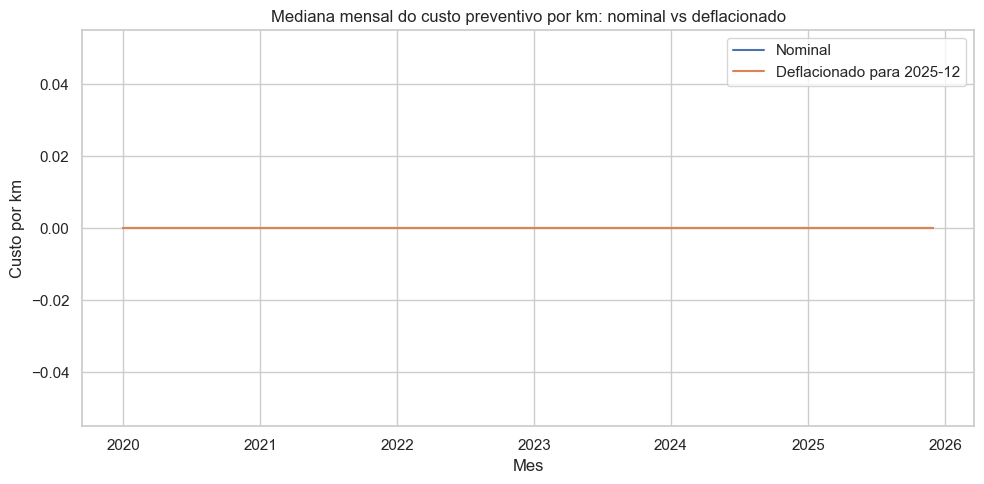

In [30]:
temporal = (
    compare.groupby("ano_mes", as_index=False)
    .agg(
        nominal=("custo_manutencao_preventiva_por_km", "median"),
        deflacionado=("custo_manutencao_preventiva_por_km_deflacionado", "median"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temporal["ano_mes"], temporal["nominal"], label="Nominal")
ax.plot(temporal["ano_mes"], temporal["deflacionado"], label="Deflacionado para 2025-12")
ax.set_title("Mediana mensal do custo preventivo por km: nominal vs deflacionado")
ax.set_xlabel("Mes")
ax.set_ylabel("Custo por km")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "04_nominal_vs_deflacionado.png", dpi=160)
plt.show()

## Takeaways

- A base deflacionada foi salva em `data/processed/base_mensal_carreta_deflacionada.csv`.
- A modelagem preditiva deve usar o alvo deflacionado como referencia principal.
- A deflacao permite interpretar variacoes de custo com menor contaminacao inflacionaria.